Cell 1: Mount Google Drive & Install Dependencies



In [1]:
# ============================================
# CELL 1: Mount Google Drive & Install Dependencies
# ============================================

from google.colab import drive
drive.mount('/content/drive')

# Create project folders in Google Drive
import os
PROJECT_DIR = '/content/drive/MyDrive/AccessoriesAI'
MODELS_DIR = os.path.join(PROJECT_DIR, 'trained_models')
DATA_DIR = os.path.join(PROJECT_DIR, 'data')
PLOTS_DIR = os.path.join(PROJECT_DIR, 'plots')

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Project Directory: {PROJECT_DIR}")
print(f"Models Directory:  {MODELS_DIR}")
print(f"Data Directory:    {DATA_DIR}")
print(f"Plots Directory:   {PLOTS_DIR}")

# Install required packages
!pip install -q torch torchvision timm pandas scikit-learn matplotlib seaborn tqdm pillow

import torch
import warnings
warnings.filterwarnings('ignore')

print(f"\n✅ Setup Complete!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ No GPU detected! Go to Runtime > Change runtime type > GPU")

Mounted at /content/drive
Project Directory: /content/drive/MyDrive/AccessoriesAI
Models Directory:  /content/drive/MyDrive/AccessoriesAI/trained_models
Data Directory:    /content/drive/MyDrive/AccessoriesAI/data
Plots Directory:   /content/drive/MyDrive/AccessoriesAI/plots

✅ Setup Complete!
PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU: Tesla T4


Cell 2: Download & Extract Kaggle Dataset

In [3]:
# ============================================
# CELL 2 (FIXED): Download Kaggle Dataset - SMALL VERSION
# ============================================

from google.colab import files
import os

# -------- Setup Kaggle API --------
os.makedirs('/root/.kaggle', exist_ok=True)

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("📤 Please upload your kaggle.json file:")
    print("   (Go to kaggle.com > Account > Create New API Token)")
    uploaded = files.upload()
    !cp kaggle.json /root/.kaggle/
    !chmod 600 /root/.kaggle/kaggle.json
else:
    print("✅ kaggle.json already exists")

# -------- Download SMALL version (only ~600MB instead of 25GB) --------
DATASET_DIR = '/content/fashion_data'

if not os.path.exists(DATASET_DIR):
    os.makedirs(DATASET_DIR, exist_ok=True)

    print("\n📥 Downloading dataset (small version ~600MB)...")
    print("   This will take 2-5 minutes...\n")

    # Download only specific files we need
    # Method 1: Download the small version
    !kaggle datasets download -d paramaggarwal/fashion-product-images-small -p {DATASET_DIR}

    # Check what was downloaded
    print("\n📦 Downloaded files:")
    !ls -lh {DATASET_DIR}/

    # Extract
    print("\n📦 Extracting dataset...")
    zip_files = [f for f in os.listdir(DATASET_DIR) if f.endswith('.zip')]

    if zip_files:
        for zf in zip_files:
            zip_path = os.path.join(DATASET_DIR, zf)
            print(f"   Extracting: {zf}")
            !unzip -q -o {zip_path} -d {DATASET_DIR}/
            # Remove zip to save space
            os.remove(zip_path)
            print(f"✅ Extracted and removed zip")
    else:
        print("⚠️ No zip files found. Checking folder structure...")

    print("\n✅ Dataset extraction complete!")
else:
    print("✅ Dataset already exists")

# -------- Auto-detect folders --------
print(f"\n🔍 Scanning dataset folder structure:")
!find {DATASET_DIR} -type d | head -20

# Auto-detect image directory
IMAGE_DIR = None
for root, dirs, dir_files in os.walk(DATASET_DIR):
    # Look for a folder containing .jpg files
    jpg_files = [f for f in dir_files if f.endswith('.jpg')]
    if len(jpg_files) > 100:  # Found image folder
        IMAGE_DIR = root
        break

# Also try common paths
if IMAGE_DIR is None:
    common_paths = [
        f'{DATASET_DIR}/images',
        f'{DATASET_DIR}/fashion-product-images-small/images',
        f'{DATASET_DIR}/myntradataset/images',
    ]
    for path in common_paths:
        if os.path.exists(path):
            IMAGE_DIR = path
            break

if IMAGE_DIR:
    total_images = len([f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')])
    sample_files = [f for f in os.listdir(IMAGE_DIR) if f.endswith('.jpg')][:5]
    print(f"\n✅ Image Directory: {IMAGE_DIR}")
    print(f"Total images: {total_images}")
    print(f"Sample files: {sample_files}")
else:
    print("\n❌ Could not find images automatically.")
    print("Listing all contents:")
    !find {DATASET_DIR} -type f | head -30

# Auto-detect styles.csv
STYLES_CSV = None
for root, dirs, dir_files in os.walk(DATASET_DIR):
    for f in dir_files:
        if f == 'styles.csv':
            STYLES_CSV = os.path.join(root, f)
            break

if STYLES_CSV:
    print(f"\n✅ Styles CSV: {STYLES_CSV}")
else:
    print("\n❌ Could not find styles.csv")
    print("Listing CSV files:")
    !find {DATASET_DIR} -name "*.csv" | head -10

# -------- Verify everything is ready --------
print(f"\n{'='*60}")
if IMAGE_DIR and STYLES_CSV:
    print("✅ DATASET READY! You can proceed to Cell 3.")
else:
    print("❌ DATASET NOT READY. See errors above.")
print(f"{'='*60}")

✅ kaggle.json already exists

📥 Downloading dataset (small version ~600MB)...
   This will take 2-5 minutes...

Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
 99% 562M/565M [00:09<00:00, 58.2MB/s]
100% 565M/565M [00:09<00:00, 60.6MB/s]

📦 Downloaded files:
total 566M
-rw-r--r-- 1 root root 566M Oct 22  2019 fashion-product-images-small.zip

📦 Extracting dataset...
   Extracting: fashion-product-images-small.zip
✅ Extracted and removed zip

✅ Dataset extraction complete!

🔍 Scanning dataset folder structure:
/content/fashion_data
/content/fashion_data/images
/content/fashion_data/myntradataset
/content/fashion_data/myntradataset/images

✅ Image Directory: /content/fashion_data/images
Total images: 44441
Sample files: ['13496.jpg', '1598.jpg', '10511.jpg', '57163.jpg', '8373.jpg']

✅ Styles CSV: /content/fashion_data/myntradataset/styles.csv

✅ DATASET READY! You can proceed to Cell 3.


Cell 3: Load & Explore Dataset

In [4]:
# ============================================
# CELL 3: Load & Explore Dataset
# ============================================

import pandas as pd

# Load the styles CSV
styles_df = pd.read_csv(STYLES_CSV, on_bad_lines='skip')

print("=" * 60)
print("📊 FULL DATASET OVERVIEW")
print("=" * 60)
print(f"Total items: {len(styles_df)}")
print(f"Columns: {list(styles_df.columns)}")

print(f"\n📦 Master Categories:")
print(styles_df['masterCategory'].value_counts())

print(f"\n🔍 Sub Categories under 'Accessories':")
acc_sub = styles_df[styles_df['masterCategory'] == 'Accessories']['subCategory'].value_counts()
print(acc_sub)

# ✅ FIX 2: Discover ALL actual articleType values for Accessories
print(f"\n📋 ALL Article Types in 'Accessories' (ACTUAL dataset values):")
print("=" * 60)
acc_articles = styles_df[styles_df['masterCategory'] == 'Accessories']['articleType'].value_counts()
for article, count in acc_articles.items():
    print(f"'{article}' → {count} items")

# Also check Apparel subcategories for possible accessories
print(f"\n📋 Article Types that might be accessories from OTHER categories:")
other_accessory_keywords = ['Jewellery', 'Watch', 'Belt', 'Scarf', 'Tie', 'Hat', 'Cap']
for keyword in other_accessory_keywords:
    matches = styles_df[styles_df['articleType'].str.contains(keyword, case=False, na=False)]
    if len(matches) > 0:
        print(f"'{keyword}' found in: {matches['masterCategory'].value_counts().to_dict()}")

print(f"\n📋 Unique Colors in dataset:")
print(styles_df['baseColour'].value_counts())

print(f"\n📋 Unique Seasons:")
print(styles_df['season'].value_counts())

print(f"\n📋 Unique Usage:")
print(styles_df['usage'].value_counts())

print(f"\n📋 Unique Gender:")
print(styles_df['gender'].value_counts())

📊 FULL DATASET OVERVIEW
Total items: 44424
Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName']

📦 Master Categories:
masterCategory
Apparel           21397
Accessories       11274
Footwear           9219
Personal Care      2403
Free Items          105
Sporting Goods       25
Home                  1
Name: count, dtype: int64

🔍 Sub Categories under 'Accessories':
subCategory
Bags                  3055
Watches               2542
Jewellery             1079
Eyewear               1073
Wallets                933
Belts                  811
Socks                  686
Headwear               293
Ties                   258
Accessories            129
Scarves                118
Cufflinks              108
Stoles                  90
Mufflers                38
Shoe Accessories        24
Gloves                  20
Water Bottle             7
Umbrellas                6
Sports Accessories       3
Perfumes                 

Cell 4: Build Category Mapping Based on ACTUAL Dataset Values

In [5]:
# ============================================
# CELL 4: Build Category Mapping from ACTUAL Dataset Values
# ============================================

# ✅ FIX 2: First, get ALL actual articleType values
actual_article_types = styles_df[styles_df['masterCategory'] == 'Accessories']['articleType'].unique()
print("📋 All ACTUAL articleType values in Accessories category:")
for at in sorted(actual_article_types):
    count = len(styles_df[styles_df['articleType'] == at])
    print(f"'{at}' → {count}")

print("\n" + "=" * 60)

# ✅ CORRECTED MAPPING: Based on actual Kaggle dataset articleType values
CATEGORY_MAPPING = {
    # Necklaces & Chains
    'Necklace': 'Necklaces & Chains',
    'Pendant': 'Necklaces & Chains',
    'Mangalsutra': 'Necklaces & Chains',
    'Chain': 'Necklaces & Chains',

    # Earrings
    'Earrings': 'Earrings',

    # Bracelets & Bangles
    'Bracelet': 'Bracelets & Bangles',
    'Bangle': 'Bracelets & Bangles',

    # Rings
    'Ring': 'Rings',

    # Watches
    'Watches': 'Watches',

    # Scarves & Shawls
    'Scarves': 'Scarves & Shawls',
    'Stoles': 'Scarves & Shawls',
    'Mufflers': 'Scarves & Shawls',
    'Dupatta': 'Scarves & Shawls',
    'Shawl': 'Scarves & Shawls',

    # Belts
    'Belts': 'Belts',
    'Suspenders': 'Belts',

    # Hats & Headwear
    'Caps': 'Hats & Headwear',
    'Hat': 'Hats & Headwear',
    'Headband': 'Hats & Headwear',

    # Sunglasses & Eyewear
    'Sunglasses': 'Sunglasses & Eyewear',

    # Handbags & Clutches (✅ FIX 3: NOT including Wallets)
    'Handbags': 'Handbags & Clutches',
    'Clutches': 'Handbags & Clutches',
    'Messenger Bag': 'Handbags & Clutches',

    # Hair Accessories
    'Hair Accessory': 'Hair Accessories',
    'Hair Band': 'Hair Accessories',

    # Ties & Bowties
    'Ties': 'Ties & Bowties',
    'Tie Pin': 'Ties & Bowties',

    # Cufflinks
    'Cufflinks': 'Cufflinks',

    # Brooches & Pins
    'Brooch': 'Brooches & Pins',
    'Badge': 'Brooches & Pins',

    # Anklets
    'Anklet': 'Anklets',
}

# Apply mapping
styles_df['mapped_category'] = styles_df['articleType'].map(CATEGORY_MAPPING)
accessories_df = styles_df.dropna(subset=['mapped_category']).copy()

print(f"✅ Total mapped accessory items: {len(accessories_df)}")
print(f"\n📦 Items per Category:")
print(accessories_df['mapped_category'].value_counts())

# ✅ FIX 5: Check for missing/empty categories
print(f"\n{'='*60}")
print("⚠️ CATEGORY HEALTH CHECK:")
print(f"{'='*60}")

expected_categories = [
    'Necklaces & Chains', 'Earrings', 'Bracelets & Bangles', 'Rings',
    'Watches', 'Scarves & Shawls', 'Belts', 'Hats & Headwear',
    'Sunglasses & Eyewear', 'Handbags & Clutches', 'Hair Accessories',
    'Brooches & Pins', 'Ties & Bowties', 'Cufflinks', 'Anklets'
]

found_categories = accessories_df['mapped_category'].unique().tolist()
categories_to_use = []

for cat in expected_categories:
    count = len(accessories_df[accessories_df['mapped_category'] == cat])
    if count > 0:
        categories_to_use.append(cat)
        print(f"✅ {cat}: {count} items")
    else:
        print(f"❌ {cat}: 0 items (WILL BE REMOVED)")

# Remove categories with 0 items
accessories_df = accessories_df[accessories_df['mapped_category'].isin(categories_to_use)].copy()

NUM_ACTUAL_CATEGORIES = len(categories_to_use)
print(f"\n✅ Final Categories to use: {NUM_ACTUAL_CATEGORIES}")
print(f"✅ Final Total Items: {len(accessories_df)}")

📋 All ACTUAL articleType values in Accessories category:
'Accessory Gift Set' → 97
'Backpacks' → 724
'Bangle' → 85
'Belts' → 813
'Bracelet' → 66
'Caps' → 283
'Clutches' → 290
'Cufflinks' → 106
'Duffel Bag' → 88
'Earrings' → 416
'Gloves' → 20
'Hair Accessory' → 1
'Handbags' → 1759
'Hat' → 3
'Headband' → 7
'Jewellery Set' → 58
'Key chain' → 2
'Laptop Bag' → 82
'Messenger Bag' → 44
'Mobile Pouch' → 47
'Mufflers' → 38
'Necklace and Chains' → 160
'Pendant' → 176
'Perfume and Body Mist' → 613
'Ring' → 118
'Rucksacks' → 11
'Scarves' → 119
'Shoe Accessories' → 23
'Shoe Laces' → 1
'Socks' → 686
'Stoles' → 90
'Sunglasses' → 1073
'Tablet Sleeve' → 3
'Ties' → 263
'Ties and Cufflinks' → 2
'Travel Accessory' → 16
'Trolley Bag' → 3
'Tshirts' → 7067
'Umbrellas' → 6
'Waist Pouch' → 17
'Wallets' → 936
'Watches' → 2542
'Water Bottle' → 11
'Wristbands' → 7

✅ Total mapped accessory items: 8448

📦 Items per Category:
mapped_category
Watches                 2542
Handbags & Clutches     2093
Sunglasses & Eye

Cell 5: Verify Images Exist & Build Clean Dataset

In [6]:
# ============================================
# CELL 5: Verify Images & Build Clean Dataset
# ============================================

import os
from tqdm import tqdm

# Verify which images actually exist on disk
valid_items = []
missing_count = 0
corrupt_count = 0

print("🔍 Verifying images exist and are readable...")
for idx, row in tqdm(accessories_df.iterrows(), total=len(accessories_df)):
    img_path = os.path.join(IMAGE_DIR, f"{int(row['id'])}.jpg")

    if os.path.exists(img_path):
        # Check if image is readable
        try:
            from PIL import Image
            img = Image.open(img_path)
            img.verify()  # Verify it's not corrupt
            valid_items.append({
                'id': int(row['id']),
                'image_path': img_path,
                'category': row['mapped_category'],
                'gender': row['gender'],
                'baseColour': row['baseColour'],
                'season': row['season'],
                'usage': row['usage'],
                'productDisplayName': row['productDisplayName']
            })
        except:
            corrupt_count += 1
    else:
        missing_count += 1

clean_df = pd.DataFrame(valid_items)

print(f"\n{'='*60}")
print(f"📊 CLEAN DATASET SUMMARY")
print(f"{'='*60}")
print(f"✅ Valid items with images: {len(clean_df)}")
print(f"❌ Missing images: {missing_count}")
print(f"⚠️ Corrupt images: {corrupt_count}")

print(f"\n📦 Category distribution:")
print(clean_df['category'].value_counts())

print(f"\n👤 Gender distribution:")
print(clean_df['gender'].value_counts())

print(f"\n🎨 Color distribution (top 20):")
print(clean_df['baseColour'].value_counts().head(20))

print(f"\n📅 Season distribution:")
print(clean_df['season'].value_counts())

print(f"\n🎯 Usage/Occasion distribution:")
print(clean_df['usage'].value_counts())

# Save clean data reference
clean_df.to_csv(os.path.join(DATA_DIR, 'accessories_raw_clean.csv'), index=False)
print(f"\n💾 Clean data saved to: {DATA_DIR}/accessories_raw_clean.csv")

🔍 Verifying images exist and are readable...


100%|██████████| 8448/8448 [00:02<00:00, 4038.64it/s]



📊 CLEAN DATASET SUMMARY
✅ Valid items with images: 8448
❌ Missing images: 0
⚠️ Corrupt images: 0

📦 Category distribution:
category
Watches                 2542
Handbags & Clutches     2093
Sunglasses & Eyewear    1073
Belts                    853
Earrings                 416
Scarves & Shawls         363
Hats & Headwear          293
Ties & Bowties           263
Necklaces & Chains       176
Bracelets & Bangles      151
Rings                    118
Cufflinks                106
Hair Accessories           1
Name: count, dtype: int64

👤 Gender distribution:
gender
Women     4572
Men       3288
Unisex     558
Girls       20
Boys        10
Name: count, dtype: int64

🎨 Color distribution (top 20):
baseColour
Black        2393
Brown         927
Silver        785
White         778
Blue          478
Gold          332
Grey          329
Steel         313
Red           311
Purple        272
Green         243
Pink          225
Beige         159
Navy Blue     115
Maroon        107
Olive          85
O

Cell 6: Handle Class Imbalance & Balance Dataset

In [7]:
# ============================================
# CELL 6: Handle Class Imbalance & Balance Dataset
# ============================================

import numpy as np
from sklearn.utils import resample

# ✅ FIX 4: Higher minimum samples
MIN_SAMPLES = 150

cat_counts = clean_df['category'].value_counts()
print("📊 Items per category BEFORE balancing:")
print(cat_counts)

print(f"\n{'='*60}")
print(f"📋 BALANCING PLAN (MIN_SAMPLES = {MIN_SAMPLES})")
print(f"{'='*60}")

# ✅ FIX 5: Remove categories with too few items (less than 10)
categories_to_keep = []
categories_to_remove = []

for cat, count in cat_counts.items():
    if count < 10:
        categories_to_remove.append(cat)
        print(f"❌ REMOVING {cat}: only {count} items (too few even for augmentation)")
    elif count < MIN_SAMPLES:
        categories_to_keep.append(cat)
        needed = MIN_SAMPLES - count
        print(f"⚠️ OVERSAMPLE {cat}: {count} → {MIN_SAMPLES} (need {needed} more)")
    else:
        categories_to_keep.append(cat)
        print(f"✅ KEEP {cat}: {count} items (sufficient)")

# Remove categories with too few items
if categories_to_remove:
    print(f"\n⚠️ Removed categories: {categories_to_remove}")
    clean_df = clean_df[~clean_df['category'].isin(categories_to_remove)].copy()

# Balance: Oversample minority classes
balanced_dfs = []
for cat in clean_df['category'].unique():
    cat_df = clean_df[clean_df['category'] == cat]
    if len(cat_df) < MIN_SAMPLES:
        cat_df_upsampled = resample(
            cat_df,
            replace=True,
            n_samples=MIN_SAMPLES,
            random_state=42
        )
        balanced_dfs.append(cat_df_upsampled)
    else:
        balanced_dfs.append(cat_df)

balanced_df = pd.concat(balanced_dfs, ignore_index=True)

# Shuffle
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n{'='*60}")
print(f"📊 AFTER BALANCING")
print(f"{'='*60}")
print(f"Total samples: {len(balanced_df)}")
print(f"Total categories: {balanced_df['category'].nunique()}")
print(f"\nCategory distribution:")
print(balanced_df['category'].value_counts())

# Verify minimum 7000 items
if len(balanced_df) >= 7000:
    print(f"\n✅ Dataset meets 7000+ requirement: {len(balanced_df)} items")
else:
    print(f"\n⚠️ Dataset has {len(balanced_df)} items. Target is 7000+")
    print("Consider adding data from DeepFashion or custom images")

📊 Items per category BEFORE balancing:
category
Watches                 2542
Handbags & Clutches     2093
Sunglasses & Eyewear    1073
Belts                    853
Earrings                 416
Scarves & Shawls         363
Hats & Headwear          293
Ties & Bowties           263
Necklaces & Chains       176
Bracelets & Bangles      151
Rings                    118
Cufflinks                106
Hair Accessories           1
Name: count, dtype: int64

📋 BALANCING PLAN (MIN_SAMPLES = 150)
✅ KEEP Watches: 2542 items (sufficient)
✅ KEEP Handbags & Clutches: 2093 items (sufficient)
✅ KEEP Sunglasses & Eyewear: 1073 items (sufficient)
✅ KEEP Belts: 853 items (sufficient)
✅ KEEP Earrings: 416 items (sufficient)
✅ KEEP Scarves & Shawls: 363 items (sufficient)
✅ KEEP Hats & Headwear: 293 items (sufficient)
✅ KEEP Ties & Bowties: 263 items (sufficient)
✅ KEEP Necklaces & Chains: 176 items (sufficient)
✅ KEEP Bracelets & Bangles: 151 items (sufficient)
⚠️ OVERSAMPLE Rings: 118 → 150 (need 32 more)
⚠

Cell 7: Encode Labels & Save Encoders

In [8]:
# ============================================
# CELL 7: Encode All Labels & Save Encoders
# ============================================

from sklearn.preprocessing import LabelEncoder
import json

# ============ CATEGORY ENCODER ============
category_encoder = LabelEncoder()
balanced_df['category_encoded'] = category_encoder.fit_transform(balanced_df['category'])

# ============ GENDER ENCODER ============
gender_encoder = LabelEncoder()
balanced_df['gender'] = balanced_df['gender'].fillna('Unisex')
# Standardize gender values
gender_map = {
    'Men': 'Men', 'Women': 'Women', 'Boys': 'Men', 'Girls': 'Women',
    'Unisex': 'Unisex'
}
balanced_df['gender'] = balanced_df['gender'].map(gender_map).fillna('Unisex')
balanced_df['gender_encoded'] = gender_encoder.fit_transform(balanced_df['gender'])

# ============ COLOR ENCODER ============
# ✅ FIX 6: Map to standard colors based on ACTUAL dataset values
print("🎨 Actual colors in dataset:")
print(balanced_df['baseColour'].value_counts())

COLOR_MAP = {
    'Black': 'Black', 'White': 'White', 'Off White': 'Off White',
    'Cream': 'Off White', 'Beige': 'Beige', 'Tan': 'Tan',
    'Brown': 'Brown', 'Coffee Brown': 'Coffee', 'Mushroom Brown': 'Brown',
    'Grey': 'Grey', 'Charcoal': 'Grey', 'Grey Melange': 'Grey',
    'Blue': 'Blue', 'Navy Blue': 'Navy Blue', 'Turquoise Blue': 'Teal',
    'Green': 'Green', 'Sea Green': 'Green', 'Olive': 'Green',
    'Lime Green': 'Green', 'Fluorescent Green': 'Green',
    'Red': 'Red', 'Maroon': 'Maroon', 'Burgundy': 'Burgundy',
    'Pink': 'Pink', 'Magenta': 'Pink', 'Mauve': 'Pink', 'Rose': 'Pink',
    'Purple': 'Purple', 'Lavender': 'Purple',
    'Orange': 'Orange', 'Rust': 'Copper', 'Peach': 'Nude',
    'Yellow': 'Yellow', 'Mustard': 'Yellow', 'Lime Yellow': 'Yellow',
    'Nude': 'Nude', 'Skin': 'Nude', 'Taupe': 'Beige',
    'Silver': 'Silver', 'Gold': 'Gold', 'Copper': 'Copper',
    'Bronze': 'Copper', 'Metallic': 'Metallic', 'Steel': 'Metallic',
    'Teal': 'Teal', 'Khaki': 'Tan',
    'Multi': 'Multi-color', 'NA': 'Multi-color'
}

balanced_df['baseColour'] = balanced_df['baseColour'].fillna('Multi-color')
balanced_df['mapped_color'] = balanced_df['baseColour'].map(COLOR_MAP).fillna('Multi-color')

color_encoder = LabelEncoder()
balanced_df['color_encoded'] = color_encoder.fit_transform(balanced_df['mapped_color'])

# ============ SEASON ENCODER ============
season_encoder = LabelEncoder()
balanced_df['season'] = balanced_df['season'].fillna('Fall')
balanced_df['season_encoded'] = season_encoder.fit_transform(balanced_df['season'])

# ============ USAGE/OCCASION ENCODER ============
USAGE_MAP = {
    'Casual': 'Casual', 'Formal': 'Formal', 'Sports': 'Sports',
    'Ethnic': 'Festive/Religious', 'Party': 'Party',
    'Smart Casual': 'Casual', 'Travel': 'Casual',
    'Home': 'Casual', 'NA': 'Casual'
}
balanced_df['usage'] = balanced_df['usage'].fillna('Casual')
balanced_df['mapped_usage'] = balanced_df['usage'].map(USAGE_MAP).fillna('Casual')

usage_encoder = LabelEncoder()
balanced_df['usage_encoded'] = usage_encoder.fit_transform(balanced_df['mapped_usage'])

# ============ PRINT ALL ENCODINGS ============
print("\n" + "=" * 60)
print("📋 LABEL ENCODINGS")
print("=" * 60)

print(f"\n📦 Categories ({len(category_encoder.classes_)}):")
for i, cat in enumerate(category_encoder.classes_):
    count = len(balanced_df[balanced_df['category'] == cat])
    print(f"{i}: {cat} ({count} items)")

print(f"\n👤 Gender ({len(gender_encoder.classes_)}):")
for i, g in enumerate(gender_encoder.classes_):
    print(f"{i}: {g}")

print(f"\n🎨 Colors ({len(color_encoder.classes_)}):")
for i, c in enumerate(color_encoder.classes_):
    count = len(balanced_df[balanced_df['mapped_color'] == c])
    print(f"{i}: {c} ({count} items)")

print(f"\n📅 Seasons ({len(season_encoder.classes_)}):")
for i, s in enumerate(season_encoder.classes_):
    print(f"{i}: {s}")

print(f"\n🎯 Usage/Occasion ({len(usage_encoder.classes_)}):")
for i, u in enumerate(usage_encoder.classes_):
    print(f"{i}: {u}")

# ============ SAVE ENCODERS ============
encoder_data = {
    'categories': list(category_encoder.classes_),
    'genders': list(gender_encoder.classes_),
    'colors': list(color_encoder.classes_),
    'seasons': list(season_encoder.classes_),
    'usages': list(usage_encoder.classes_),
    'num_categories': len(category_encoder.classes_),
    'num_genders': len(gender_encoder.classes_),
    'num_colors': len(color_encoder.classes_),
    'num_seasons': len(season_encoder.classes_),
    'num_usages': len(usage_encoder.classes_),
}

encoder_path = os.path.join(MODELS_DIR, 'accessory_label_encoders.json')
with open(encoder_path, 'w') as f:
    json.dump(encoder_data, f, indent=2)

print(f"\n💾 Label encoders saved to: {encoder_path}")

# Store counts for model initialization
NUM_CATEGORIES = len(category_encoder.classes_)
NUM_GENDERS = len(gender_encoder.classes_)
NUM_COLORS = len(color_encoder.classes_)
NUM_SEASONS = len(season_encoder.classes_)
NUM_USAGES = len(usage_encoder.classes_)

print(f"\n✅ Encoding complete!")
print(f"Categories: {NUM_CATEGORIES} | Genders: {NUM_GENDERS} | Colors: {NUM_COLORS} | Seasons: {NUM_SEASONS} | Usages: {NUM_USAGES}")

🎨 Actual colors in dataset:
baseColour
Black                2398
Brown                 927
Silver                807
White                 779
Blue                  477
Gold                  343
Steel                 341
Grey                  329
Red                   312
Purple                271
Green                 243
Pink                  227
Beige                 159
Navy Blue             116
Maroon                107
Olive                  85
Orange                 77
Yellow                 73
Copper                 59
Cream                  59
Multi                  44
Off White              42
Metallic               30
Teal                   30
Lavender               29
Bronze                 26
Mustard                19
Tan                    19
Peach                  17
Khaki                  14
Charcoal               12
Magenta                11
Turquoise Blue          8
Rust                    7
Burgundy                6
Mauve                   5
Coffee Brown            5

Cell 8: Create PyTorch Dataset & DataLoaders

In [9]:
# ============================================
# CELL 8: Create PyTorch Dataset & DataLoaders
# ============================================

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split

# ============ DATA TRANSFORMS ============
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.1)
])

val_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# ============ DATASET CLASS ============
class AccessoryDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = row['image_path']

        # Load image safely
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), (128, 128, 128))

        if self.transform:
            image = self.transform(image)

        targets = {
            'category': torch.tensor(row['category_encoded'], dtype=torch.long),
            'gender': torch.tensor(row['gender_encoded'], dtype=torch.long),
            'color': torch.tensor(row['color_encoded'], dtype=torch.long),
            'season': torch.tensor(row['season_encoded'], dtype=torch.long),
            'usage': torch.tensor(row['usage_encoded'], dtype=torch.long),
        }

        return image, targets

# ============ TRAIN/VAL/TEST SPLIT ============
train_df, temp_df = train_test_split(
    balanced_df, test_size=0.2,
    stratify=balanced_df['category_encoded'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5,
    stratify=temp_df['category_encoded'],
    random_state=42
)

print(f"📊 Data Split:")
print(f"Training:   {len(train_df)} samples ({len(train_df)/len(balanced_df)*100:.1f}%)")
print(f"Validation: {len(val_df)} samples ({len(val_df)/len(balanced_df)*100:.1f}%)")
print(f"Test:       {len(test_df)} samples ({len(test_df)/len(balanced_df)*100:.1f}%)")

# Create datasets
train_dataset = AccessoryDataset(train_df, transform=train_transform)
val_dataset = AccessoryDataset(val_df, transform=val_transform)
test_dataset = AccessoryDataset(test_df, transform=val_transform)

# Create dataloaders
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

# Verify a batch
images, targets = next(iter(train_loader))
print(f"\n🔍 Batch Verification:")
print(f"Image batch shape: {images.shape}")
print(f"Category targets:  {targets['category'][:8].tolist()}")
print(f"Gender targets:    {targets['gender'][:8].tolist()}")
print(f"Color targets:     {targets['color'][:8].tolist()}")
print(f"\n✅ DataLoaders created successfully!")

📊 Data Split:
Training:   6818 samples (80.0%)
Validation: 852 samples (10.0%)
Test:       853 samples (10.0%)

🔍 Batch Verification:
Image batch shape: torch.Size([32, 3, 224, 224])
Category targets:  [11, 0, 4, 5, 11, 9, 0, 0]
Gender targets:    [0, 2, 2, 0, 0, 0, 2, 2]
Color targets:     [1, 19, 17, 10, 3, 11, 1, 8]

✅ DataLoaders created successfully!


Cell 9: Build Multi-Head ResNet-152 Model

In [10]:
# ============================================
# CELL 9: Build Multi-Head ResNet-152 Model
# ============================================

import torch.nn as nn
import torchvision.models as models

class AccessoryClassifier(nn.Module):
    """
    Multi-head ResNet-152 classifier for accessories.
    Predicts: category, gender, color, season, usage/occasion simultaneously.
    Uses shared feature extraction with separate classification heads.
    """
    def __init__(self, num_categories, num_genders, num_colors,
                 num_seasons, num_usages):
        super(AccessoryClassifier, self).__init__()

        # Load pretrained ResNet-152
        self.backbone = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V2)

        # Get feature dimension (2048 for ResNet-152)
        num_features = self.backbone.fc.in_features

        # Remove original FC layer
        self.backbone.fc = nn.Identity()

        # Shared feature layers
        self.shared_fc = nn.Sequential(
            nn.Linear(num_features, 1024),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.2),
        )

        # Classification heads
        self.category_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_categories)
        )

        self.gender_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_genders)
        )

        self.color_head = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(256, num_colors)
        )

        self.season_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_seasons)
        )

        self.usage_head = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, num_usages)
        )

    def forward(self, x):
        features = self.backbone(x)
        shared = self.shared_fc(features)

        return {
            'category': self.category_head(shared),
            'gender': self.gender_head(shared),
            'color': self.color_head(shared),
            'season': self.season_head(shared),
            'usage': self.usage_head(shared),
            'features': shared  # Return shared features for later use (Model 2/3)
        }

# ============ INITIALIZE MODEL ============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = AccessoryClassifier(
    num_categories=NUM_CATEGORIES,
    num_genders=NUM_GENDERS,
    num_colors=NUM_COLORS,
    num_seasons=NUM_SEASONS,
    num_usages=NUM_USAGES
).to(device)

# ✅ FIX 7: Freeze backbone initially (Stage 1 training)
print("🔒 Freezing ResNet-152 backbone for initial training...")
for param in model.backbone.parameters():
    param.requires_grad = False

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print(f"\n📊 Model Summary:")
print(f"   Device: {device}")
print(f"   Total parameters:     {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Frozen parameters:    {frozen_params:,}")
print(f"\n   Architecture:")
print(f"   Backbone: ResNet-152 (pretrained, FROZEN)")
print(f"   Shared FC: 2048 → 1024 → 512")
print(f"   Category Head: 512 → 256 → {NUM_CATEGORIES}")
print(f"   Gender Head:   512 → 128 → {NUM_GENDERS}")
print(f"   Color Head:    512 → 256 → {NUM_COLORS}")
print(f"   Season Head:   512 → 128 → {NUM_SEASONS}")
print(f"   Usage Head:    512 → 128 → {NUM_USAGES}")
print(f"\n✅ Model created! (Backbone FROZEN for Stage 1)")

Downloading: "https://download.pytorch.org/models/resnet152-f82ba261.pth" to /root/.cache/torch/hub/checkpoints/resnet152-f82ba261.pth


100%|██████████| 230M/230M [00:01<00:00, 173MB/s]


🔒 Freezing ResNet-152 backbone for initial training...

📊 Model Summary:
   Device: cuda
   Total parameters:     61,240,561
   Trainable parameters: 3,096,753
   Frozen parameters:    58,143,808

   Architecture:
   Backbone: ResNet-152 (pretrained, FROZEN)
   Shared FC: 2048 → 1024 → 512
   Category Head: 512 → 256 → 12
   Gender Head:   512 → 128 → 3
   Color Head:    512 → 256 → 25
   Season Head:   512 → 128 → 4
   Usage Head:    512 → 128 → 5

✅ Model created! (Backbone FROZEN for Stage 1)


Cell 10: Define Loss Functions, Optimizer & Scheduler

In [11]:
# ============================================
# CELL 10: Loss Functions, Optimizer & Scheduler
# ============================================

import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

# ============ CLASS WEIGHTS FOR CATEGORY ============
category_counts = balanced_df['category_encoded'].value_counts().sort_index()
total_samples = len(balanced_df)
category_weights = torch.tensor(
    [total_samples / (NUM_CATEGORIES * count) for count in category_counts.values],
    dtype=torch.float32
).to(device)

# ============ LOSS FUNCTIONS ============
criterion_category = nn.CrossEntropyLoss(weight=category_weights)
criterion_gender = nn.CrossEntropyLoss()
criterion_color = nn.CrossEntropyLoss()
criterion_season = nn.CrossEntropyLoss()
criterion_usage = nn.CrossEntropyLoss()

# Loss weights (category is most important)
LOSS_WEIGHTS = {
    'category': 2.0,
    'gender': 1.0,
    'color': 1.5,
    'season': 0.8,
    'usage': 1.0
}

# ============ OPTIMIZER (only trainable params) ============
optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,  # Higher LR since backbone is frozen
    weight_decay=1e-4
)

# ============ SCHEDULER ============
NUM_EPOCHS_STAGE1 = 10  # Frozen backbone
NUM_EPOCHS_STAGE2 = 15  # Unfrozen backbone
NUM_EPOCHS_TOTAL = NUM_EPOCHS_STAGE1 + NUM_EPOCHS_STAGE2

scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-6)

# ============ EARLY STOPPING CONFIG ============
PATIENCE = 7
UNFREEZE_EPOCH = NUM_EPOCHS_STAGE1  # Unfreeze after this epoch

print("⚙️ Training Configuration:")
print(f"   Stage 1: Epochs 1-{NUM_EPOCHS_STAGE1} (backbone FROZEN, lr=1e-3)")
print(f"   Stage 2: Epochs {NUM_EPOCHS_STAGE1+1}-{NUM_EPOCHS_TOTAL} (backbone UNFROZEN, lr=1e-5)")
print(f"   Total Epochs: {NUM_EPOCHS_TOTAL}")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Early Stopping Patience: {PATIENCE}")
print(f"   Optimizer: AdamW")
print(f"   Scheduler: CosineAnnealingWarmRestarts")
print(f"\n   Loss Weights:")
for k, v in LOSS_WEIGHTS.items():
    print(f"      {k}: {v}")
print(f"\n   Category Class Weights:")
for i, w in enumerate(category_weights):
    print(f"      {category_encoder.classes_[i]}: {w:.4f}")
print(f"\n✅ Training configuration set!")

⚙️ Training Configuration:
   Stage 1: Epochs 1-10 (backbone FROZEN, lr=1e-3)
   Stage 2: Epochs 11-25 (backbone UNFROZEN, lr=1e-5)
   Total Epochs: 25
   Batch Size: 32
   Early Stopping Patience: 7
   Optimizer: AdamW
   Scheduler: CosineAnnealingWarmRestarts

   Loss Weights:
      category: 2.0
      gender: 1.0
      color: 1.5
      season: 0.8
      usage: 1.0

   Category Class Weights:
      Belts: 0.8326
      Bracelets & Bangles: 4.7036
      Cufflinks: 4.7350
      Earrings: 1.7073
      Handbags & Clutches: 0.3393
      Hats & Headwear: 2.4241
      Necklaces & Chains: 4.0355
      Rings: 4.7350
      Scarves & Shawls: 1.9566
      Sunglasses & Eyewear: 0.6619
      Ties & Bowties: 2.7006
      Watches: 0.2794

✅ Training configuration set!


Cell 11: Training Loop with 2-Stage Fine-tuning & Early Stopping

In [12]:
# ============================================
# CELL 11: Training Loop (2-Stage + Early Stopping)
# ============================================

from tqdm import tqdm
import time

def calculate_loss(outputs, targets):
    """Calculate weighted multi-task loss."""
    loss = (
        LOSS_WEIGHTS['category'] * criterion_category(outputs['category'], targets['category']) +
        LOSS_WEIGHTS['gender'] * criterion_gender(outputs['gender'], targets['gender']) +
        LOSS_WEIGHTS['color'] * criterion_color(outputs['color'], targets['color']) +
        LOSS_WEIGHTS['season'] * criterion_season(outputs['season'], targets['season']) +
        LOSS_WEIGHTS['usage'] * criterion_usage(outputs['usage'], targets['usage'])
    )
    return loss

def train_one_epoch(model, dataloader, optimizer, device):
    model.train()
    total_loss = 0
    correct = {'category': 0, 'gender': 0, 'color': 0, 'season': 0, 'usage': 0}
    total = 0

    for images, targets in tqdm(dataloader, desc="  Training", leave=False):
        images = images.to(device)
        targets = {k: v.to(device) for k, v in targets.items()}

        optimizer.zero_grad()
        outputs = model(images)
        loss = calculate_loss(outputs, targets)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        total += images.size(0)

        for key in correct:
            _, predicted = torch.max(outputs[key], 1)
            correct[key] += (predicted == targets[key]).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracies = {k: v / total * 100 for k, v in correct.items()}
    return avg_loss, accuracies

def validate(model, dataloader, device):
    model.eval()
    total_loss = 0
    correct = {'category': 0, 'gender': 0, 'color': 0, 'season': 0, 'usage': 0}
    total = 0

    with torch.no_grad():
        for images, targets in tqdm(dataloader, desc="  Validating", leave=False):
            images = images.to(device)
            targets = {k: v.to(device) for k, v in targets.items()}

            outputs = model(images)
            loss = calculate_loss(outputs, targets)

            total_loss += loss.item()
            total += images.size(0)

            for key in correct:
                _, predicted = torch.max(outputs[key], 1)
                correct[key] += (predicted == targets[key]).sum().item()

    avg_loss = total_loss / len(dataloader)
    accuracies = {k: v / total * 100 for k, v in correct.items()}
    return avg_loss, accuracies

# ==================== START TRAINING ====================
print("=" * 70)
print("🚀 STARTING TRAINING - Accessory Classifier (ResNet-152)")
print("   2-Stage Fine-tuning with Early Stopping")
print("=" * 70)

best_val_acc = 0
best_epoch = 0
patience_counter = 0
history = {
    'train_loss': [], 'val_loss': [],
    'train_cat_acc': [], 'val_cat_acc': [],
    'train_color_acc': [], 'val_color_acc': [],
    'train_gender_acc': [], 'val_gender_acc': [],
    'lr': []
}

start_total = time.time()

for epoch in range(NUM_EPOCHS_TOTAL):
    start_time = time.time()

    # ✅ FIX 7: Stage 2 - Unfreeze backbone after Stage 1
    if epoch == UNFREEZE_EPOCH:
        print(f"\n{'='*70}")
        print(f"🔓 STAGE 2: Unfreezing ResNet-152 backbone for fine-tuning!")
        print(f"{'='*70}")

        for param in model.backbone.parameters():
            param.requires_grad = True

        # New optimizer with differential learning rates
        optimizer = optim.AdamW([
            {'params': model.backbone.parameters(), 'lr': 1e-5},       # Lower LR for backbone
            {'params': model.shared_fc.parameters(), 'lr': 5e-5},
            {'params': model.category_head.parameters(), 'lr': 5e-5},
            {'params': model.gender_head.parameters(), 'lr': 5e-5},
            {'params': model.color_head.parameters(), 'lr': 5e-5},
            {'params': model.season_head.parameters(), 'lr': 5e-5},
            {'params': model.usage_head.parameters(), 'lr': 5e-5},
        ], weight_decay=1e-4)

        scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=5, T_mult=2, eta_min=1e-7)

        trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"   Trainable parameters: {trainable:,}\n")

    # Train
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, device)

    # Validate
    val_loss, val_acc = validate(model, val_loader, device)

    # Step scheduler
    scheduler.step()

    epoch_time = time.time() - start_time
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_cat_acc'].append(train_acc['category'])
    history['val_cat_acc'].append(val_acc['category'])
    history['train_color_acc'].append(train_acc['color'])
    history['val_color_acc'].append(val_acc['color'])
    history['train_gender_acc'].append(train_acc['gender'])
    history['val_gender_acc'].append(val_acc['gender'])
    history['lr'].append(current_lr)

    # Determine stage
    stage = "Stage 1 (Frozen)" if epoch < UNFREEZE_EPOCH else "Stage 2 (Fine-tune)"

    # Print progress
    print(f"\n📈 Epoch [{epoch+1}/{NUM_EPOCHS_TOTAL}] - {stage} ({epoch_time:.1f}s)")
    print(f"   Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"   Train → Cat: {train_acc['category']:.1f}% | Color: {train_acc['color']:.1f}% | Gender: {train_acc['gender']:.1f}% | Season: {train_acc['season']:.1f}% | Usage: {train_acc['usage']:.1f}%")
    print(f"   Val   → Cat: {val_acc['category']:.1f}% | Color: {val_acc['color']:.1f}% | Gender: {val_acc['gender']:.1f}% | Season: {val_acc['season']:.1f}% | Usage: {val_acc['usage']:.1f}%")
    print(f"   LR: {current_lr:.8f}")

    # Save best model
    if val_acc['category'] > best_val_acc:
        best_val_acc = val_acc['category']
        best_epoch = epoch + 1
        patience_counter = 0

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_accuracy': val_acc,
            'train_accuracy': train_acc,
            'val_loss': val_loss,
            'num_categories': NUM_CATEGORIES,
            'num_genders': NUM_GENDERS,
            'num_colors': NUM_COLORS,
            'num_seasons': NUM_SEASONS,
            'num_usages': NUM_USAGES,
            'category_classes': list(category_encoder.classes_),
            'gender_classes': list(gender_encoder.classes_),
            'color_classes': list(color_encoder.classes_),
            'season_classes': list(season_encoder.classes_),
            'usage_classes': list(usage_encoder.classes_),
        }, os.path.join(MODELS_DIR, 'accessory_classifier_resnet152_best.pth'))
        print(f"   💾 Best model saved! (Val Cat Acc: {best_val_acc:.1f}%)")
    else:
        patience_counter += 1
        print(f"   ⏳ No improvement ({patience_counter}/{PATIENCE})")

        # ✅ FIX 8: Early stopping
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping at epoch {epoch+1}!")
            print(f"   No improvement for {PATIENCE} epochs.")
            break

total_time = time.time() - start_total

print(f"\n{'='*70}")
print(f"✅ TRAINING COMPLETE!")
print(f"   Best Epoch: {best_epoch}")
print(f"   Best Val Category Accuracy: {best_val_acc:.1f}%")
print(f"   Total Training Time: {total_time/60:.1f} minutes")
print(f"{'='*70}")

🚀 STARTING TRAINING - Accessory Classifier (ResNet-152)
   2-Stage Fine-tuning with Early Stopping



📈 Epoch [1/25] - Stage 1 (Frozen) (63.0s)
   Train Loss: 6.8021 | Val Loss: 5.6298
   Train → Cat: 75.2% | Color: 41.5% | Gender: 70.5% | Season: 70.0% | Usage: 89.7%
   Val   → Cat: 90.4% | Color: 42.5% | Gender: 74.6% | Season: 70.9% | Usage: 90.4%
   LR: 0.00090460
   💾 Best model saved! (Val Cat Acc: 90.4%)



📈 Epoch [2/25] - Stage 1 (Frozen) (64.5s)
   Train Loss: 5.5200 | Val Loss: 4.7652
   Train → Cat: 84.3% | Color: 47.1% | Gender: 75.6% | Season: 73.6% | Usage: 90.8%
   Val   → Cat: 94.2% | Color: 48.4% | Gender: 78.1% | Season: 76.6% | Usage: 89.6%
   LR: 0.00065485
   💾 Best model saved! (Val Cat Acc: 94.2%)



📈 Epoch [3/25] - Stage 1 (Frozen) (66.2s)
   Train Loss: 4.9428 | Val Loss: 4.8129
   Train → Cat: 86.7% | Color: 49.5% | Gender: 77.3% | Season: 74.4% | Usage: 91.1%
   Val   → Cat: 94.5% | Color: 50.4% | Gender: 78.2% | Season: 77.9% | Usage: 88.6%
   LR: 0.00034615
   💾 Best model saved! (Val Cat Acc: 94.5%)



📈 Epoch [4/25] - Stage 1 (Frozen) (66.0s)
   Train Loss: 4.6812 | Val Loss: 4.4280
   Train → Cat: 88.4% | Color: 51.9% | Gender: 77.7% | Season: 74.5% | Usage: 91.7%
   Val   → Cat: 95.3% | Color: 52.0% | Gender: 79.0% | Season: 76.1% | Usage: 92.0%
   LR: 0.00009640
   💾 Best model saved! (Val Cat Acc: 95.3%)


...


📈 Epoch [21/25] - Stage 2 (Fine-tune) (170.0s)
   Train Loss: 2.7255 | Val Loss: 2.9772
   Train → Cat: 97.9% | Color: 64.1% | Gender: 85.9% | Season: 79.1% | Usage: 94.0%
   Val   → Cat: 98.7% | Color: 62.1% | Gender: 84.5% | Season: 77.8% | Usage: 93.8%
   LR: 0.00000352
   💾 Best model saved! (Val Cat Acc: 98.7%)



📈 Epoch [22/25] - Stage 2 (Fine-tune) (170.3s)
   Train Loss: 2.6844 | Val Loss: 3.0673
   Train → Cat: 97.9% | Color: 64.4% | Gender: 86.3% | Season: 79.3% | Usage: 93.7%
   Val   → Cat: 98.2% | Color: 62.3% | Gender: 83.9% | Season: 78.2% | Usage: 94.0%
   LR: 0.00000214
   ⏳ No improvement (1/7)



📈 Epoch [23/25] - Stage 2 (Fine-tune) (170.3s)
   Train Loss: 2.6320 | Val Loss: 2.9455
   Train → Cat: 98.5% | Color: 65.3% | Gender: 86.0% | Season: 79.3% | Usage: 93.8%
   Val   → Cat: 98.6% | Color: 62.9% | Gender: 84.7% | Season: 78.6% | Usage: 93.7%
   LR: 0.00000105
   ⏳ No improvement (2/7)



📈 Epoch [24/25] - Stage 2 (Fine-tune) (170.4s)
   Train Loss: 2.6182 | Val Loss: 2.9708
   Train → Cat: 98.2% | Color: 65.1% | Gender: 86.6% | Season: 79.3% | Usage: 93.9%
   Val   → Cat: 98.4% | Color: 62.6% | Gender: 84.9% | Season: 78.9% | Usage: 93.8%
   LR: 0.00000034
   ⏳ No improvement (3/7)



📈 Epoch [25/25] - Stage 2 (Fine-tune) (170.1s)
   Train Loss: 2.6250 | Val Loss: 2.9921
   Train → Cat: 98.4% | Color: 65.3% | Gender: 86.5% | Season: 78.8% | Usage: 93.8%
   Val   → Cat: 98.4% | Color: 63.4% | Gender: 84.7% | Season: 78.8% | Usage: 94.0%
   LR: 0.00001000
   ⏳ No improvement (4/7)

✅ TRAINING COMPLETE!
   Best Epoch: 21
   Best Val Category Accuracy: 98.7%
   Total Training Time: 53.9 minutes


Cell 12: Plot Training History

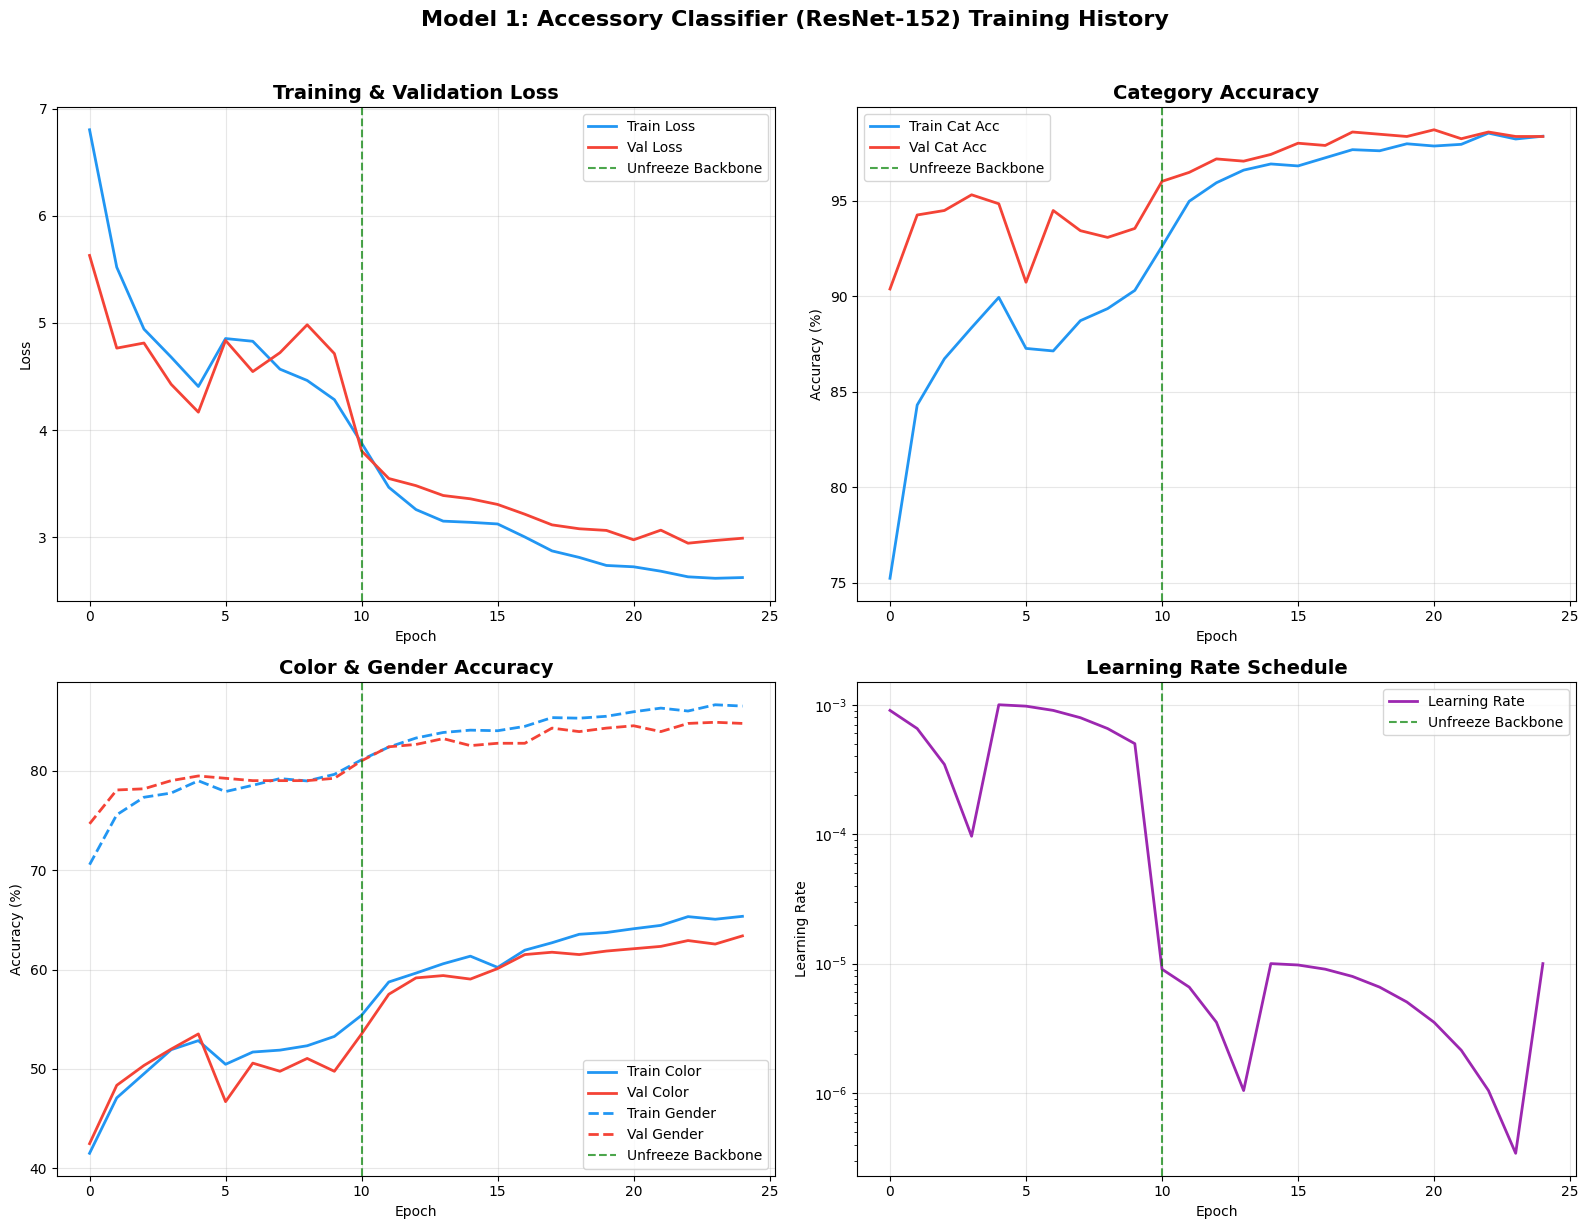

✅ Training history plots saved!


In [13]:
# ============================================
# CELL 12: Plot Training History
# ============================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ---- Plot 1: Loss ----
axes[0, 0].plot(history['train_loss'], label='Train Loss', color='#2196F3', linewidth=2)
axes[0, 0].plot(history['val_loss'], label='Val Loss', color='#F44336', linewidth=2)
axes[0, 0].axvline(x=UNFREEZE_EPOCH, color='green', linestyle='--', alpha=0.7, label='Unfreeze Backbone')
axes[0, 0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# ---- Plot 2: Category Accuracy ----
axes[0, 1].plot(history['train_cat_acc'], label='Train Cat Acc', color='#2196F3', linewidth=2)
axes[0, 1].plot(history['val_cat_acc'], label='Val Cat Acc', color='#F44336', linewidth=2)
axes[0, 1].axvline(x=UNFREEZE_EPOCH, color='green', linestyle='--', alpha=0.7, label='Unfreeze Backbone')
axes[0, 1].set_title('Category Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# ---- Plot 3: Color & Gender Accuracy ----
axes[1, 0].plot(history['train_color_acc'], label='Train Color', color='#2196F3', linewidth=2, linestyle='-')
axes[1, 0].plot(history['val_color_acc'], label='Val Color', color='#F44336', linewidth=2, linestyle='-')
axes[1, 0].plot(history['train_gender_acc'], label='Train Gender', color='#2196F3', linewidth=2, linestyle='--')
axes[1, 0].plot(history['val_gender_acc'], label='Val Gender', color='#F44336', linewidth=2, linestyle='--')
axes[1, 0].axvline(x=UNFREEZE_EPOCH, color='green', linestyle='--', alpha=0.7, label='Unfreeze Backbone')
axes[1, 0].set_title('Color & Gender Accuracy', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# ---- Plot 4: Learning Rate ----
axes[1, 1].plot(history['lr'], label='Learning Rate', color='#9C27B0', linewidth=2)
axes[1, 1].axvline(x=UNFREEZE_EPOCH, color='green', linestyle='--', alpha=0.7, label='Unfreeze Backbone')
axes[1, 1].set_title('Learning Rate Schedule', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_yscale('log')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Model 1: Accessory Classifier (ResNet-152) Training History',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model1_training_history.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training history plots saved!")

Cell 13: Evaluate on Test Set

In [16]:
# ============================================
# CELL 13 (FIXED): Evaluate on Test Set with Full Report
# ============================================

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Load best model
checkpoint = torch.load(os.path.join(MODELS_DIR, 'accessory_classifier_resnet152_best.pth'))
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"📥 Loaded best model from Epoch {checkpoint['epoch']}")

# Collect all predictions
all_preds = {'category': [], 'gender': [], 'color': [], 'season': [], 'usage': []}
all_labels = {'category': [], 'gender': [], 'color': [], 'season': [], 'usage': []}

with torch.no_grad():
    for images, targets in tqdm(test_loader, desc="🔍 Testing"):
        images = images.to(device)
        outputs = model(images)

        for key in all_preds:
            probs = torch.softmax(outputs[key], dim=1)
            _, predicted = torch.max(probs, 1)
            all_preds[key].extend(predicted.cpu().numpy())
            all_labels[key].extend(targets[key].numpy())

# ============ CATEGORY REPORT ============
print("\n" + "=" * 70)
print("📊 CATEGORY CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    all_labels['category'], all_preds['category'],
    labels=list(range(len(category_encoder.classes_))),
    target_names=category_encoder.classes_,
    digits=3,
    zero_division=0
))

# ============ GENDER REPORT ============
print("\n" + "=" * 70)
print("📊 GENDER CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    all_labels['gender'], all_preds['gender'],
    labels=list(range(len(gender_encoder.classes_))),
    target_names=gender_encoder.classes_,
    digits=3,
    zero_division=0
))

# ============ COLOR REPORT (FIXED) ============
print("\n" + "=" * 70)
print("📊 COLOR CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    all_labels['color'], all_preds['color'],
    labels=list(range(len(color_encoder.classes_))),
    target_names=color_encoder.classes_,
    digits=3,
    zero_division=0
))

# ============ SEASON REPORT ============
print("\n" + "=" * 70)
print("📊 SEASON CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    all_labels['season'], all_preds['season'],
    labels=list(range(len(season_encoder.classes_))),
    target_names=season_encoder.classes_,
    digits=3,
    zero_division=0
))

# ============ USAGE REPORT ============
print("\n" + "=" * 70)
print("📊 USAGE/OCCASION CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(
    all_labels['usage'], all_preds['usage'],
    labels=list(range(len(usage_encoder.classes_))),
    target_names=usage_encoder.classes_,
    digits=3,
    zero_division=0
))

# ============ OVERALL SUMMARY ============
print("\n" + "=" * 70)
print("📊 OVERALL TEST ACCURACY SUMMARY")
print("=" * 70)
for key in all_preds:
    acc = np.mean(np.array(all_preds[key]) == np.array(all_labels[key])) * 100
    print(f"   {key.capitalize():12s}: {acc:.2f}%")

cat_acc = np.mean(np.array(all_preds['category']) == np.array(all_labels['category'])) * 100
if cat_acc >= 87:
    print(f"\n✅ Category accuracy ({cat_acc:.1f}%) meets research requirement (>87%)")
else:
    print(f"\n⚠️ Category accuracy ({cat_acc:.1f}%) is below 87% target.")

📥 Loaded best model from Epoch 21


🔍 Testing: 100%|██████████| 27/27 [00:06<00:00,  4.27it/s]


📊 CATEGORY CLASSIFICATION REPORT
                      precision    recall  f1-score   support

               Belts      1.000     0.977     0.988        86
 Bracelets & Bangles      0.882     1.000     0.938        15
           Cufflinks      1.000     0.933     0.966        15
            Earrings      0.977     1.000     0.988        42
 Handbags & Clutches      0.995     0.995     0.995       210
     Hats & Headwear      1.000     1.000     1.000        29
  Necklaces & Chains      0.850     1.000     0.919        17
               Rings      1.000     0.933     0.966        15
    Scarves & Shawls      0.973     1.000     0.986        36
Sunglasses & Eyewear      1.000     0.991     0.995       108
      Ties & Bowties      1.000     1.000     1.000        26
             Watches      1.000     0.992     0.996       254

            accuracy                          0.991       853
           macro avg      0.973     0.985     0.978       853
        weighted avg      0.991   

Cell 14: Confusion Matrix

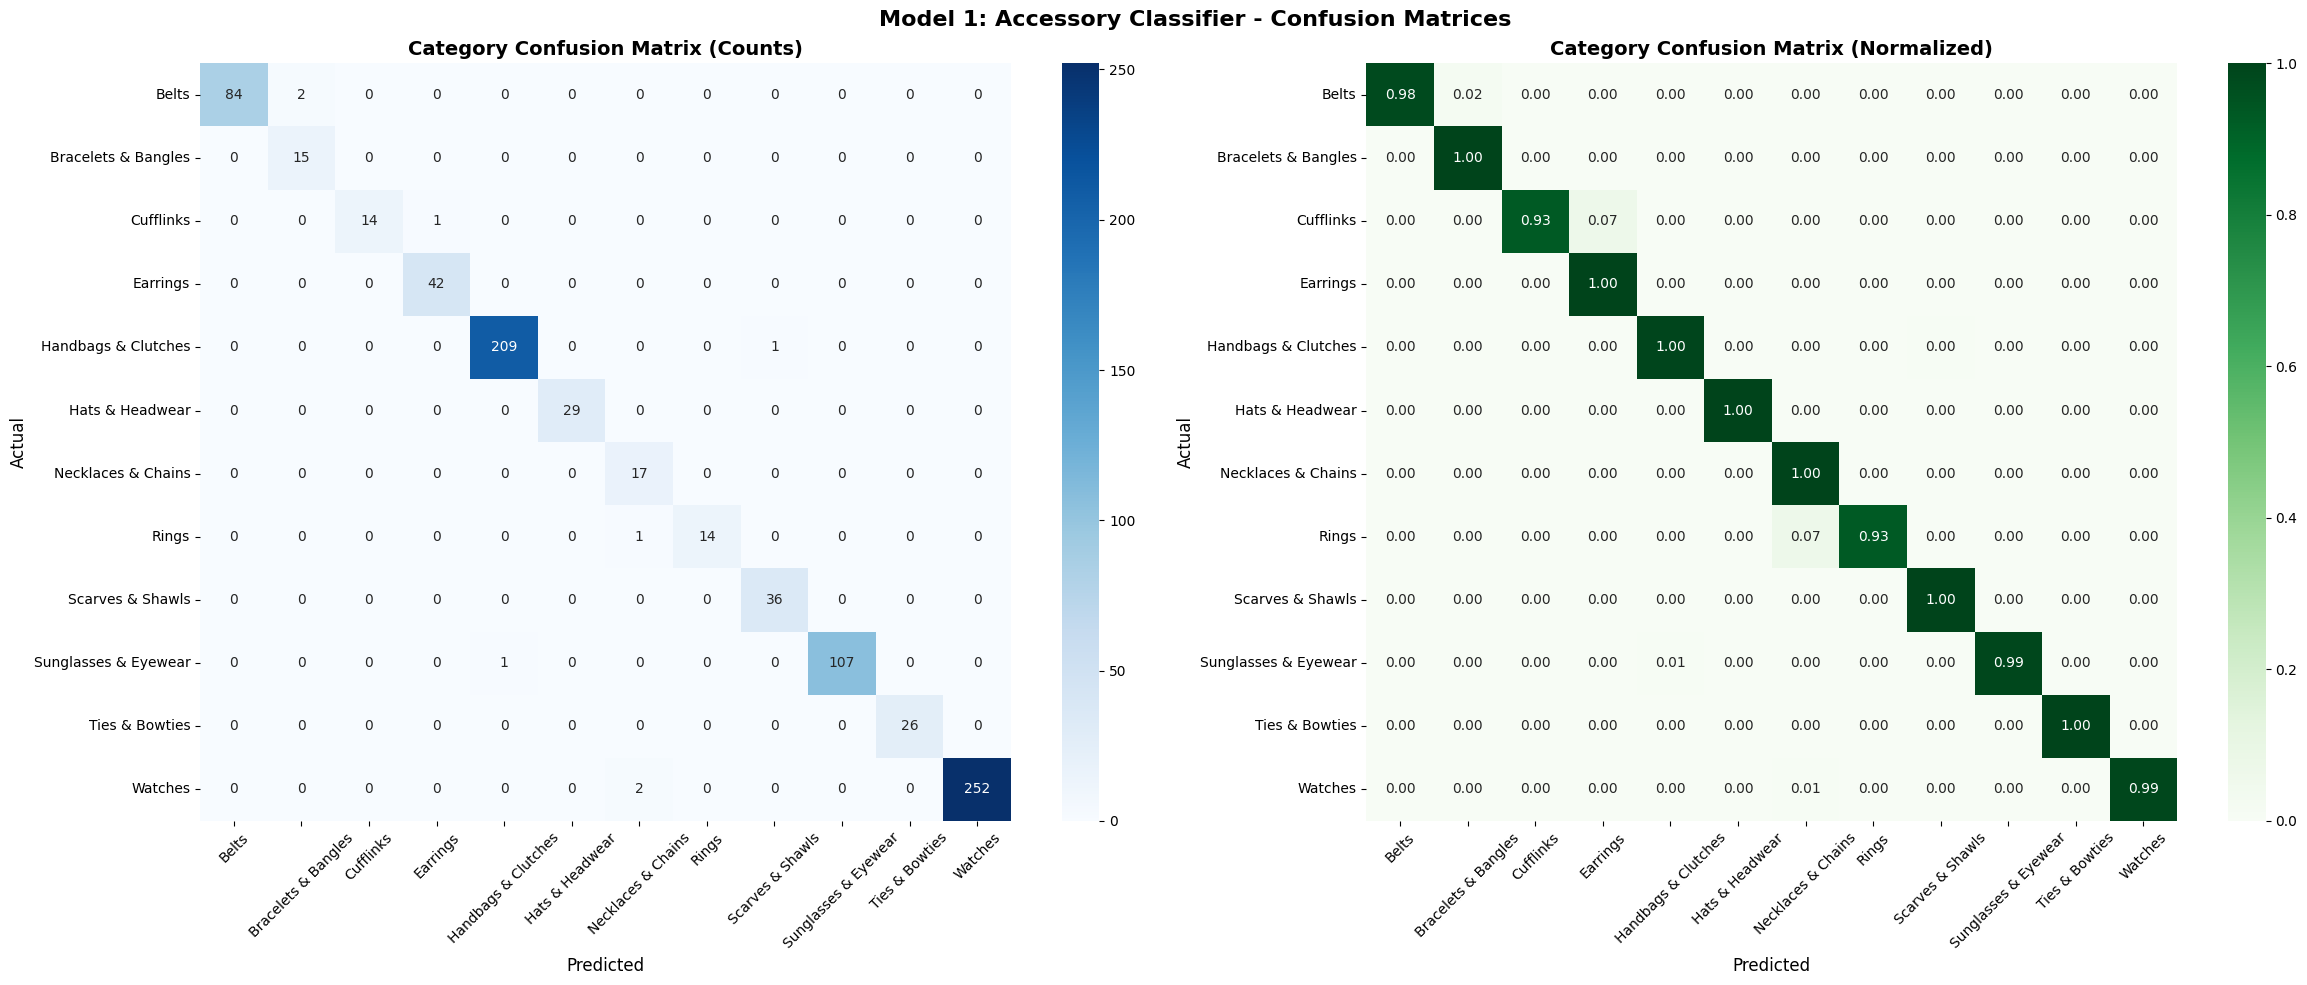

✅ Confusion matrices saved!


In [17]:
# ============================================
# CELL 14: Confusion Matrix Visualization
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Category Confusion Matrix
cm = confusion_matrix(all_labels['category'], all_preds['category'])

# Normalize for better visualization
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=category_encoder.classes_,
            yticklabels=category_encoder.classes_,
            ax=axes[0])
axes[0].set_title('Category Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Normalized (percentages)
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=category_encoder.classes_,
            yticklabels=category_encoder.classes_,
            ax=axes[1])
axes[1].set_title('Category Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Model 1: Accessory Classifier - Confusion Matrices',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model1_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved!")

Cell 15: Test with Sample Images (Visual Predictions)

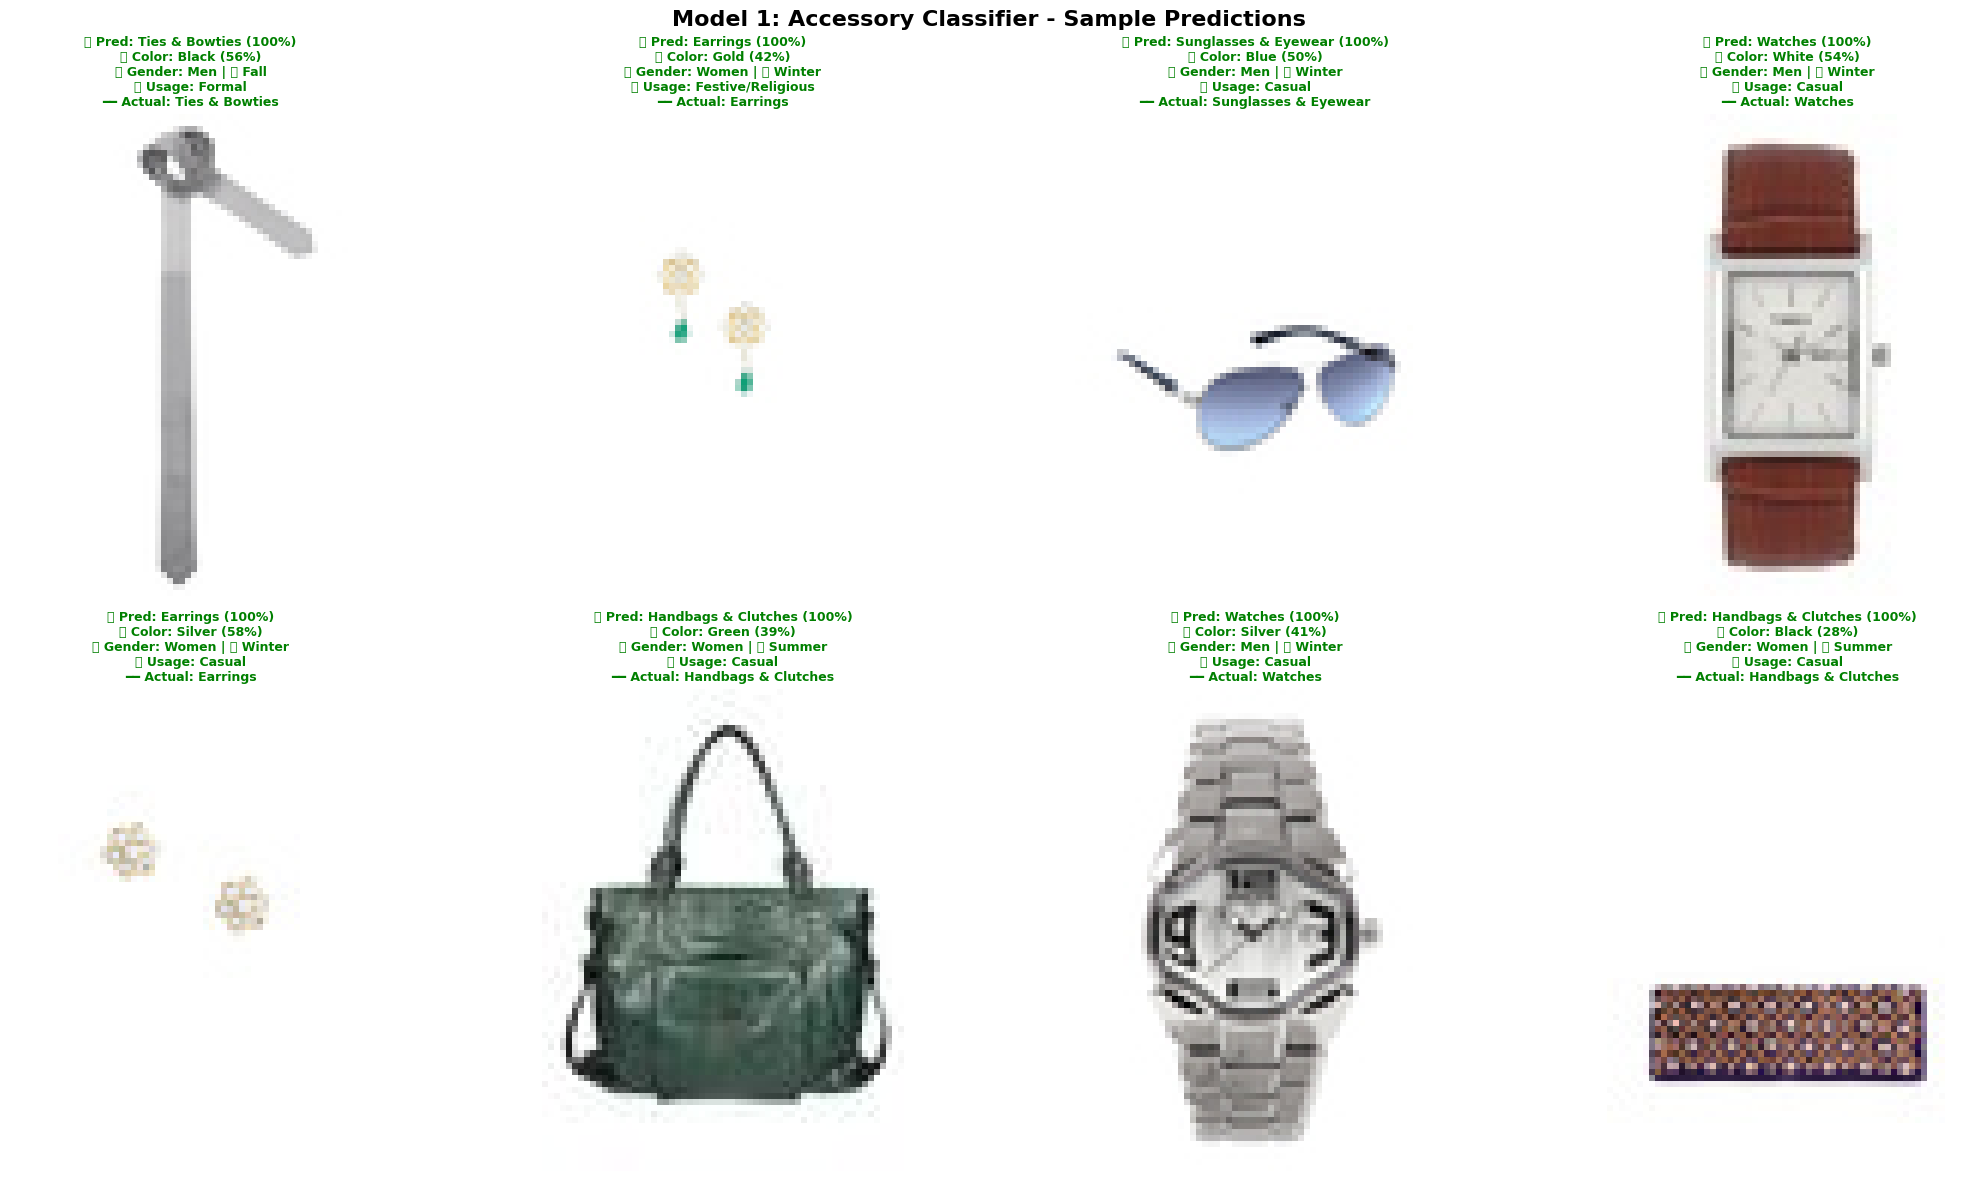

✅ Sample predictions displayed and saved!


In [18]:
# ============================================
# CELL 15: Visual Prediction on Sample Images
# ============================================

import random
from PIL import Image
import matplotlib.pyplot as plt

def predict_accessory(model, image_path, device):
    """Predict all attributes for a single accessory image."""
    model.eval()

    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(input_tensor)

    predictions = {}
    confidences = {}

    encoders = {
        'category': category_encoder,
        'gender': gender_encoder,
        'color': color_encoder,
        'season': season_encoder,
        'usage': usage_encoder
    }

    for key, encoder in encoders.items():
        probs = torch.softmax(outputs[key], dim=1)
        conf, pred_idx = torch.max(probs, 1)
        predictions[key] = encoder.classes_[pred_idx.item()]
        confidences[key] = conf.item() * 100

    return predictions, confidences

# Test on 8 random samples
fig, axes = plt.subplots(2, 4, figsize=(22, 12))
sample_indices = random.sample(range(len(test_df)), 8)

for ax, idx in zip(axes.flat, sample_indices):
    row = test_df.iloc[idx]
    img = Image.open(row['image_path']).convert('RGB')
    preds, confs = predict_accessory(model, row['image_path'], device)

    is_correct = preds['category'] == row['category']

    ax.imshow(img)
    title_text = (
        f"{'✅' if is_correct else '❌'} Pred: {preds['category']} ({confs['category']:.0f}%)\n"
        f"🎨 Color: {preds['color']} ({confs['color']:.0f}%)\n"
        f"👤 Gender: {preds['gender']} | 📅 {preds['season']}\n"
        f"🎯 Usage: {preds['usage']}\n"
        f"━━ Actual: {row['category']}"
    )
    ax.set_title(title_text, fontsize=9,
                 color='green' if is_correct else 'red',
                 fontweight='bold')
    ax.axis('off')

plt.suptitle('Model 1: Accessory Classifier - Sample Predictions',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'model1_sample_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample predictions displayed and saved!")

Cell 16: Save Final Model + Inference Model for Backend

In [19]:
# ============================================
# CELL 16: Save Final Model & All Artifacts
# ============================================

import json

# ✅ FIX 9: Save inference-only model (smaller, for backend deployment)
# Load best model
checkpoint = torch.load(os.path.join(MODELS_DIR, 'accessory_classifier_resnet152_best.pth'))
model.load_state_dict(checkpoint['model_state_dict'])

# Save inference-only version (no optimizer state = smaller file)
inference_save = {
    'model_state_dict': model.state_dict(),
    'num_categories': NUM_CATEGORIES,
    'num_genders': NUM_GENDERS,
    'num_colors': NUM_COLORS,
    'num_seasons': NUM_SEASONS,
    'num_usages': NUM_USAGES,
    'category_classes': list(category_encoder.classes_),
    'gender_classes': list(gender_encoder.classes_),
    'color_classes': list(color_encoder.classes_),
    'season_classes': list(season_encoder.classes_),
    'usage_classes': list(usage_encoder.classes_),
    'input_size': [3, 224, 224],
    'normalize_mean': [0.485, 0.456, 0.406],
    'normalize_std': [0.229, 0.224, 0.225],
}

torch.save(inference_save, os.path.join(MODELS_DIR, 'accessory_classifier_resnet152_inference.pth'))

# Save complete model info as JSON
model_info = {
    'model_name': 'AccessoryClassifier_ResNet152',
    'architecture': 'ResNet-152 Multi-Head (2-Stage Fine-tuned)',
    'input_size': [224, 224, 3],
    'num_categories': NUM_CATEGORIES,
    'num_genders': NUM_GENDERS,
    'num_colors': NUM_COLORS,
    'num_seasons': NUM_SEASONS,
    'num_usages': NUM_USAGES,
    'category_classes': list(category_encoder.classes_),
    'gender_classes': list(gender_encoder.classes_),
    'color_classes': list(color_encoder.classes_),
    'season_classes': list(season_encoder.classes_),
    'usage_classes': list(usage_encoder.classes_),
    'best_epoch': best_epoch,
    'best_val_category_accuracy': round(best_val_acc, 2),
    'training_config': {
        'stage1_epochs': NUM_EPOCHS_STAGE1,
        'stage2_epochs': NUM_EPOCHS_STAGE2,
        'batch_size': BATCH_SIZE,
        'optimizer': 'AdamW',
        'stage1_lr': 1e-3,
        'stage2_backbone_lr': 1e-5,
        'stage2_heads_lr': 5e-5,
        'early_stopping_patience': PATIENCE,
    },
    'dataset': {
        'name': 'Kaggle Fashion Product Images',
        'total_training_samples': len(train_df),
        'total_validation_samples': len(val_df),
        'total_test_samples': len(test_df),
        'total_balanced_samples': len(balanced_df),
        'min_samples_per_category': MIN_SAMPLES,
    },
    'loss_weights': LOSS_WEIGHTS,
}

with open(os.path.join(MODELS_DIR, 'model1_info.json'), 'w') as f:
    json.dump(model_info, f, indent=2)

# Save balanced dataset for other models
balanced_df.to_csv(os.path.join(DATA_DIR, 'accessories_balanced.csv'), index=False)

# Save training history
import pickle
with open(os.path.join(MODELS_DIR, 'model1_history.pkl'), 'wb') as f:
    pickle.dump(history, f)

# ============ PRINT ALL SAVED FILES ============
print("=" * 60)
print("📁 ALL SAVED FILES IN GOOGLE DRIVE")
print("=" * 60)

print(f"\n📂 {MODELS_DIR}/")
for f_name in sorted(os.listdir(MODELS_DIR)):
    size = os.path.getsize(os.path.join(MODELS_DIR, f_name))
    if size > 1024 * 1024:
        print(f"   📄 {f_name} ({size / (1024*1024):.1f} MB)")
    else:
        print(f"   📄 {f_name} ({size / 1024:.1f} KB)")

print(f"\n📂 {DATA_DIR}/")
for f_name in sorted(os.listdir(DATA_DIR)):
    size = os.path.getsize(os.path.join(DATA_DIR, f_name))
    if size > 1024 * 1024:
        print(f"   📄 {f_name} ({size / (1024*1024):.1f} MB)")
    else:
        print(f"   📄 {f_name} ({size / 1024:.1f} KB)")

print(f"\n📂 {PLOTS_DIR}/")
for f_name in sorted(os.listdir(PLOTS_DIR)):
    size = os.path.getsize(os.path.join(PLOTS_DIR, f_name))
    print(f"   📄 {f_name} ({size / 1024:.1f} KB)")

📁 ALL SAVED FILES IN GOOGLE DRIVE

📂 /content/drive/MyDrive/AccessoriesAI/trained_models/
   📄 accessory_classifier_resnet152_best.pth (702.2 MB)
   📄 accessory_classifier_resnet152_inference.pth (234.5 MB)
   📄 accessory_label_encoders.json (0.9 KB)
   📄 model1_history.pkl (2.2 KB)
   📄 model1_info.json (1.8 KB)

📂 /content/drive/MyDrive/AccessoriesAI/data/
   📄 accessories_balanced.csv (1.2 MB)
   📄 accessories_raw_clean.csv (979.4 KB)

📂 /content/drive/MyDrive/AccessoriesAI/plots/
   📄 model1_confusion_matrix.png (244.9 KB)
   📄 model1_sample_predictions.png (186.2 KB)
   📄 model1_training_history.png (301.5 KB)


Cell 17: Final Verification — Test Single Image Prediction Function

In [20]:
# ============================================
# CELL 17: Final Verification - Backend-Ready Prediction Function
# ============================================

def predict_from_image_path(image_path):
    """
    Backend-ready function: Takes an image path, returns all predictions.
    This is exactly how the Flask backend will use the model.
    """
    # Load inference model
    checkpoint = torch.load(
        os.path.join(MODELS_DIR, 'accessory_classifier_resnet152_inference.pth'),
        map_location=device
    )

    # Rebuild model
    inference_model = AccessoryClassifier(
        num_categories=checkpoint['num_categories'],
        num_genders=checkpoint['num_genders'],
        num_colors=checkpoint['num_colors'],
        num_seasons=checkpoint['num_seasons'],
        num_usages=checkpoint['num_usages']
    ).to(device)
    inference_model.load_state_dict(checkpoint['model_state_dict'])
    inference_model.eval()

    # Transform
    transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=checkpoint['normalize_mean'],
            std=checkpoint['normalize_std']
        )
    ])

    # Predict
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = inference_model(input_tensor)

    result = {}
    class_maps = {
        'category': checkpoint['category_classes'],
        'gender': checkpoint['gender_classes'],
        'color': checkpoint['color_classes'],
        'season': checkpoint['season_classes'],
        'usage': checkpoint['usage_classes'],
    }

    for key, classes in class_maps.items():
        probs = torch.softmax(outputs[key], dim=1)
        confidence, pred_idx = torch.max(probs, 1)
        result[key] = {
            'prediction': classes[pred_idx.item()],
            'confidence': round(confidence.item() * 100, 2),
            'top3': []
        }
        # Get top 3 predictions
        top3_probs, top3_indices = torch.topk(probs, min(3, len(classes)), dim=1)
        for prob, idx in zip(top3_probs[0], top3_indices[0]):
            result[key]['top3'].append({
                'label': classes[idx.item()],
                'confidence': round(prob.item() * 100, 2)
            })

    return result

# Test with a random image
test_sample = test_df.iloc[random.randint(0, len(test_df)-1)]
print(f"🖼️ Testing with: {test_sample['productDisplayName']}")
print(f"   Actual Category: {test_sample['category']}")
print(f"   Image: {test_sample['image_path']}")

result = predict_from_image_path(test_sample['image_path'])

print(f"\n{'='*60}")
print(f"🔮 PREDICTION RESULTS (Backend Format)")
print(f"{'='*60}")

for key, data in result.items():
    print(f"\n   {key.upper()}:")
    print(f"   → {data['prediction']} ({data['confidence']}%)")
    print(f"   Top 3:")
    for i, t in enumerate(data['top3'], 1):
        print(f"     {i}. {t['label']} ({t['confidence']}%)")

print(f"\n{'='*60}")
print(f"✅ MODEL 1 TRAINING 100% COMPLETE!")
print(f"{'='*60}")
print(f"\n📋 Summary:")
print(f"   Model: AccessoryClassifier_ResNet152")
print(f"   Categories: {NUM_CATEGORIES}")
print(f"   Best Val Accuracy: {best_val_acc:.1f}%")
print(f"   Total Data Used: {len(balanced_df)} items")
print(f"   Saved To: {MODELS_DIR}")
print(f"\n🚀 Ready for Model 2: Dress Attribute Extractor!")

🖼️ Testing with: Lino Perros Unisex Beige Sling Bag
   Actual Category: Handbags & Clutches
   Image: /content/fashion_data/images/57846.jpg

🔮 PREDICTION RESULTS (Backend Format)

   CATEGORY:
   → Handbags & Clutches (99.96%)
   Top 3:
     1. Handbags & Clutches (99.96%)
     2. Hats & Headwear (0.02%)
     3. Belts (0.02%)

   GENDER:
   → Women (96.14%)
   Top 3:
     1. Women (96.14%)
     2. Unisex (3.65%)
     3. Men (0.21%)

   COLOR:
   → Brown (39.43%)
   Top 3:
     1. Brown (39.43%)
     2. Beige (30.81%)
     3. Grey (12.59%)

   SEASON:
   → Summer (58.85%)
   Top 3:
     1. Summer (58.85%)
     2. Winter (26.38%)
     3. Fall (14.64%)

   USAGE:
   → Casual (99.89%)
   Top 3:
     1. Casual (99.89%)
     2. Festive/Religious (0.07%)
     3. Party (0.02%)

✅ MODEL 1 TRAINING 100% COMPLETE!

📋 Summary:
   Model: AccessoryClassifier_ResNet152
   Categories: 12
   Best Val Accuracy: 98.7%
   Total Data Used: 8523 items
   Saved To: /content/drive/MyDrive/AccessoriesAI/train